# Exploratory Data Analysis

**Objective:** Understand the structure and characteristics of the sales data and image dataset before modelling.

**Inputs:**
- `data/raw/sales.xlsx` — transactional sales records
- `data/raw/images/` — product design images organised in four folders

**Sections:**
1. Sales data structure and quality
2. Temporal patterns
3. Product-level aggregation
4. Price and quantity distributions
5. Image inventory
6. Image–product code mapping investigation
7. Summary of findings

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
SALES_PATH = DATA_RAW / 'sales.xlsx'
IMAGES_DIR = DATA_RAW / 'images'

print('Project root :', PROJECT_ROOT)
print('Sales file   :', SALES_PATH.exists())
print('Images dir   :', IMAGES_DIR.exists())

Project root : E:\POC\project-poc
Sales file   : True
Images dir   : True


## 1. Sales data structure and quality

In [2]:
sales_raw = pd.read_excel(SALES_PATH, sheet_name='sales data')
print('Shape (raw):', sales_raw.shape)
sales_raw.head()

Shape (raw): (704, 4)


,date,code,qty,rate
0,2026-04-22 14:50:52.085,500001,16,1296
1,2026-04-22 14:50:52.085,500001,4,1295
2,2026-04-22 14:50:52.085,500001,16,1295
3,2026-04-22 14:50:52.085,500001,4,1295
4,2026-04-22 14:50:52.085,10029028,4,1250


In [3]:
expected_cols = ['date', 'code', 'qty', 'rate']
sales = sales_raw[expected_cols].dropna(how='all').copy()
sales = sales.dropna(subset=['date', 'code'])
sales['code'] = sales['code'].astype(int)
sales['date'] = pd.to_datetime(sales['date'])

print('Shape (clean):', sales.shape)
print('\nDtypes:')
print(sales.dtypes)
print('\nMissing values per column:')
print(sales.isna().sum())
print('\nDuplicate rows:', sales.duplicated().sum())

Shape (clean): (704, 4)

Dtypes:
date    datetime64[ns]
code             int32
qty              int64
rate             int64
dtype: object

Missing values per column:
date    0
code    0
qty     0
rate    0
dtype: int64

Duplicate rows: 7


In [4]:
print('Unique product codes :', sales['code'].nunique())
print('Total transactions   :', len(sales))
print('Date range           :', sales['date'].min(), 'to', sales['date'].max())
print('Qty   min/max/mean   :', sales['qty'].min(), '/', sales['qty'].max(), '/', round(sales['qty'].mean(), 2))
print('Rate  min/max/mean   :', sales['rate'].min(), '/', sales['rate'].max(), '/', round(sales['rate'].mean(), 2))
sales.describe()

Unique product codes : 146
Total transactions   : 704
Date range           : 2025-07-23 18:23:53 to 2026-04-28 19:38:02.002000
Qty   min/max/mean   : 1 / 100 / 5.7
Rate  min/max/mean   : 335 / 1650 / 947.08


,date,code,qty,rate
count,704,7.040000e+02,704.000000,704.000000
mean,2026-03-27 05:16:06.223533824,9.255981e+06,5.704545,947.075284
min,2025-07-23 18:23:53,5.000010e+05,1.000000,335.000000
25%,2026-04-02 19:00:07.671500032,1.002582e+07,4.000000,775.000000
50%,2026-04-17 15:54:48.745499904,1.002781e+07,4.000000,975.000000
75%,2026-04-24 19:07:17.996000,1.002883e+07,4.000000,1150.000000
max,2026-04-28 19:38:02.002000,1.002946e+07,100.000000,1650.000000
std,NaN,2.600752e+06,8.654959,289.262610


## 2. Temporal patterns

In [5]:
sales['month'] = sales['date'].dt.to_period('M').astype(str)
monthly = sales.groupby('month').agg(
    transactions=('qty', 'size'),
    total_qty=('qty', 'sum'),
    unique_products=('code', 'nunique')
).reset_index()
monthly

,month,transactions,total_qty,unique_products
0,2025-07,3,12,1
1,2025-09,15,148,2
2,2025-10,8,93,3
3,2025-11,22,215,5
4,2025-12,12,88,3
5,2026-01,21,132,5
6,2026-02,56,393,9
7,2026-03,19,269,8
8,2026-04,548,2666,143


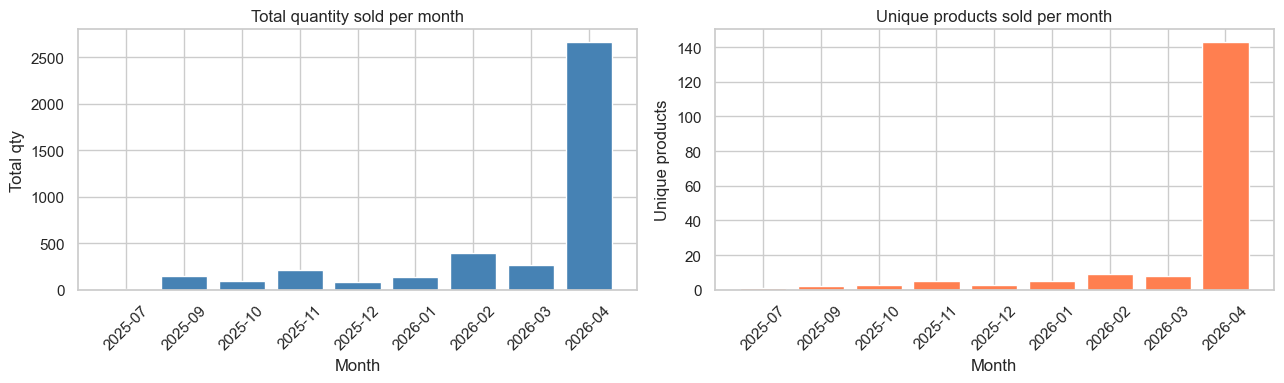

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(monthly['month'], monthly['total_qty'], color='steelblue')
axes[0].set_title('Total quantity sold per month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total qty')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(monthly['month'], monthly['unique_products'], color='coral')
axes[1].set_title('Unique products sold per month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Unique products')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Product-level aggregation

Per-product summary table — this becomes the target table for modelling.

In [7]:
product_summary = sales.groupby('code').agg(
    total_qty=('qty', 'sum'),
    avg_qty=('qty', 'mean'),
    transactions=('qty', 'size'),
    avg_rate=('rate', 'mean'),
    min_rate=('rate', 'min'),
    max_rate=('rate', 'max'),
    first_sale=('date', 'min'),
    last_sale=('date', 'max')
).reset_index()
product_summary['active_days'] = (product_summary['last_sale'] - product_summary['first_sale']).dt.days

print('Products:', len(product_summary))
product_summary.describe()

Products: 146


,code,total_qty,avg_qty,transactions,avg_rate,min_rate,max_rate,first_sale,last_sale,active_days
count,1.460000e+02,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146,146,146.000000
mean,9.963018e+06,27.506849,4.868564,4.821918,900.721011,900.582192,900.897260,2026-04-09 11:52:51.312191488,2026-04-24 14:10:19.244301568,14.705479
min,5.000010e+05,3.000000,3.000000,1.000000,335.000000,335.000000,335.000000,2025-07-23 18:23:53,2026-03-14 12:56:24.452000,0.000000
25%,1.002783e+07,8.000000,4.000000,2.000000,750.000000,750.000000,750.000000,2026-04-09 15:16:13.253249792,2026-04-23 20:34:52.349500160,0.000000
50%,1.002893e+07,12.500000,4.000000,3.000000,875.000000,875.000000,875.000000,2026-04-21 14:25:29.457999872,2026-04-27 15:41:04.459000064,3.500000
75%,1.002927e+07,27.250000,5.000000,5.750000,1017.500000,1017.500000,1017.500000,2026-04-27 11:34:27.080000,2026-04-28 15:43:28.896000,12.750000
max,1.002946e+07,1032.000000,18.105263,57.000000,1650.000000,1650.000000,1650.000000,2026-04-28 19:38:02.002000,2026-04-28 19:38:02.002000,278.000000
std,7.885683e+05,85.754601,1.850078,6.020293,230.256199,230.098562,230.476619,NaN,NaN,36.988007


In [8]:
top10 = product_summary.nlargest(10, 'total_qty')[['code', 'total_qty', 'transactions', 'avg_rate']]
print('Top 10 products by total quantity sold:')
top10

Top 10 products by total quantity sold:


,code,total_qty,transactions,avg_rate
0,500001,1032,57,1295.017544
46,10028268,110,24,335.000000
5,10022091,84,19,1250.000000
47,10028269,72,8,335.000000
9,10025542,71,20,1170.250000
18,10027298,68,16,1150.000000
19,10027299,64,15,1150.000000
6,10022578,60,13,1195.000000
7,10025103,60,14,1195.000000
31,10027735,57,16,975.000000


In [9]:
bottom10 = product_summary.nsmallest(10, 'total_qty')[['code', 'total_qty', 'transactions', 'avg_rate']]
print('Bottom 10 products by total quantity sold:')
bottom10

Bottom 10 products by total quantity sold:


,code,total_qty,transactions,avg_rate
73,10028959,3,1,1095.0
20,10027514,4,1,950.0
29,10027703,4,1,750.0
55,10028629,4,1,875.0
82,10029107,4,1,775.0
84,10029120,4,1,1195.0
85,10029122,4,1,995.0
86,10029123,4,1,995.0
92,10029142,4,1,850.0
96,10029230,4,1,750.0


## 4. Price and quantity distributions

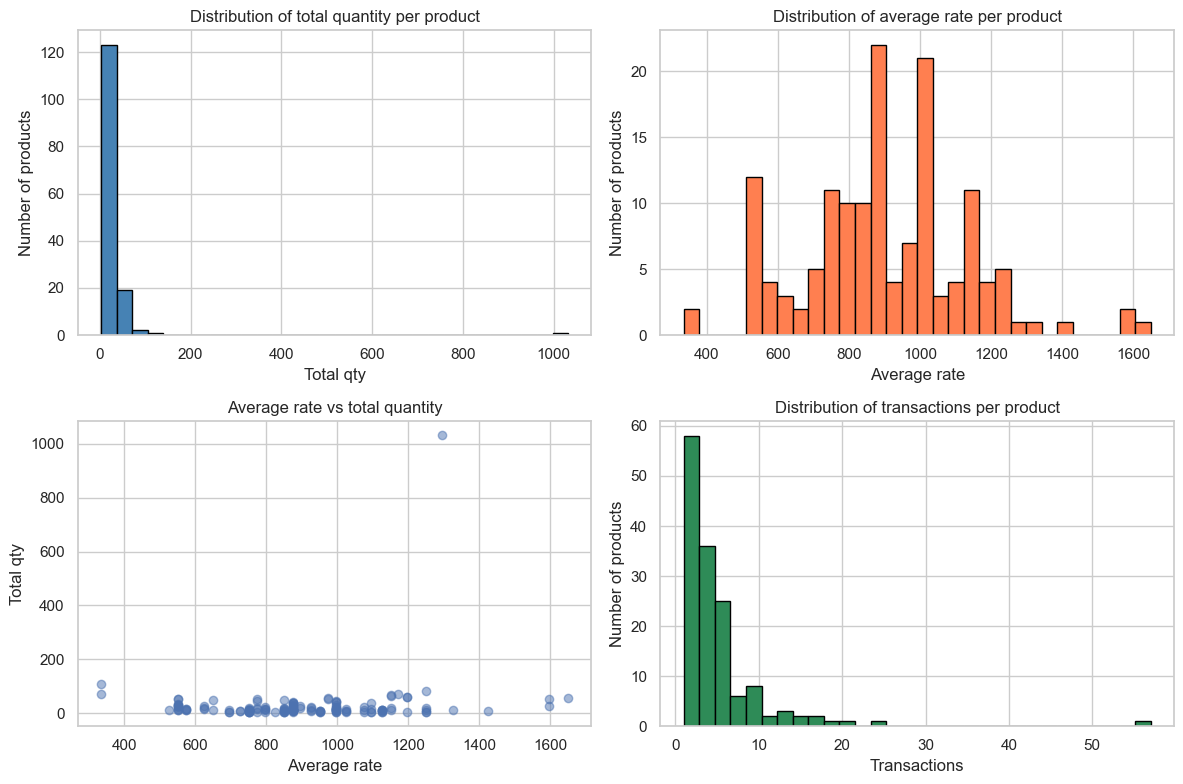

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(product_summary['total_qty'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of total quantity per product')
axes[0, 0].set_xlabel('Total qty')
axes[0, 0].set_ylabel('Number of products')

axes[0, 1].hist(product_summary['avg_rate'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of average rate per product')
axes[0, 1].set_xlabel('Average rate')
axes[0, 1].set_ylabel('Number of products')

axes[1, 0].scatter(product_summary['avg_rate'], product_summary['total_qty'], alpha=0.5)
axes[1, 0].set_title('Average rate vs total quantity')
axes[1, 0].set_xlabel('Average rate')
axes[1, 0].set_ylabel('Total qty')

axes[1, 1].hist(product_summary['transactions'], bins=30, color='seagreen', edgecolor='black')
axes[1, 1].set_title('Distribution of transactions per product')
axes[1, 1].set_xlabel('Transactions')
axes[1, 1].set_ylabel('Number of products')

plt.tight_layout()
plt.show()

In [11]:
correlation = product_summary[['total_qty', 'avg_qty', 'transactions', 'avg_rate']].corr()
print('Correlation matrix:')
correlation

Correlation matrix:


,total_qty,avg_qty,transactions,avg_rate
total_qty,1.000000,0.602949,0.847771,0.139431
avg_qty,0.602949,1.000000,0.364413,-0.052468
transactions,0.847771,0.364413,1.000000,0.162355
avg_rate,0.139431,-0.052468,0.162355,1.000000


## 5. Image inventory

In [12]:
image_records = []
for folder in sorted(os.listdir(IMAGES_DIR)):
    folder_path = IMAGES_DIR / folder
    if not folder_path.is_dir():
        continue
    for fname in sorted(os.listdir(folder_path)):
        fpath = folder_path / fname
        if fpath.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
            image_records.append({
                'folder': folder,
                'filename': fname,
                'path': str(fpath),
                'size_kb': round(fpath.stat().st_size / 1024, 1)
            })

images_df = pd.DataFrame(image_records)
print('Total images:', len(images_df))
print('\nImages per folder:')
print(images_df['folder'].value_counts().sort_index())
print('\nFile size summary (KB):')
print(images_df['size_kb'].describe())

Total images: 180

Images per folder:
folder
1    55
2    52
3    36
4    37
Name: count, dtype: int64

File size summary (KB):
count    180.000000
mean     451.550000
std      117.906031
min      142.300000
25%      378.075000
50%      458.300000
75%      527.550000
max      762.300000
Name: size_kb, dtype: float64


In [13]:
sample_dims = []
for path in images_df['path'].sample(min(20, len(images_df)), random_state=42):
    with Image.open(path) as im:
        sample_dims.append({'path': path, 'width': im.width, 'height': im.height, 'mode': im.mode})
dims_df = pd.DataFrame(sample_dims)
print('Sampled image dimensions (n=20):')
print(dims_df[['width', 'height', 'mode']].describe(include='all'))

Sampled image dimensions (n=20):
              width       height mode
count     20.000000    20.000000   20
unique          NaN          NaN    1
top             NaN          NaN  RGB
freq            NaN          NaN   20
mean    1156.500000  1523.750000  NaN
std      173.378958   157.303553  NaN
min      800.000000  1195.000000  NaN
25%     1066.750000  1600.000000  NaN
50%     1200.000000  1600.000000  NaN
75%     1200.000000  1600.000000  NaN
max     1600.000000  1600.000000  NaN


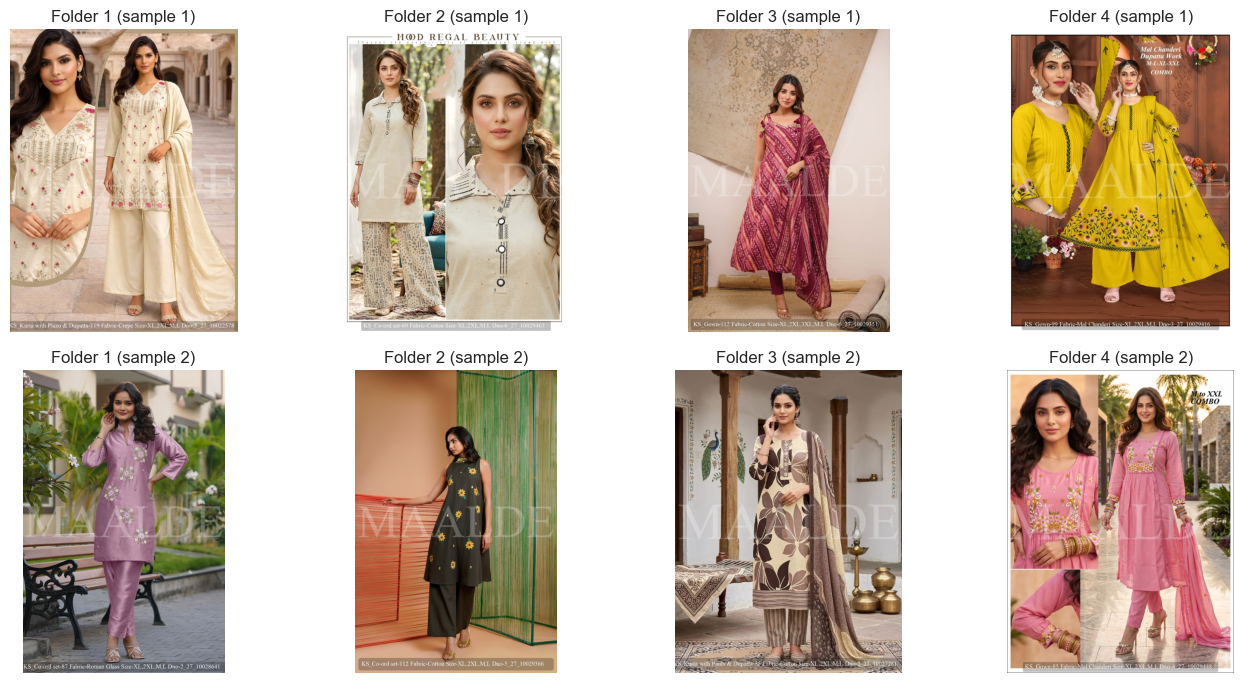

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, folder in zip(axes[0], sorted(images_df['folder'].unique())):
    sample_path = images_df[images_df['folder'] == folder]['path'].iloc[0]
    with Image.open(sample_path) as im:
        ax.imshow(im)
    ax.set_title(f'Folder {folder} (sample 1)')
    ax.axis('off')

for ax, folder in zip(axes[1], sorted(images_df['folder'].unique())):
    samples = images_df[images_df['folder'] == folder]['path']
    sample_path = samples.iloc[len(samples) // 2]
    with Image.open(sample_path) as im:
        ax.imshow(im)
    ax.set_title(f'Folder {folder} (sample 2)')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Image–product code mapping investigation

Filenames are WhatsApp-style timestamps and do not directly contain product codes. We investigate whether the four folders correspond to product categories in the sales data.

In [15]:
print('Total images       :', len(images_df))
print('Unique product codes:', sales['code'].nunique())
print('Difference         :', len(images_df) - sales['code'].nunique())

Total images       : 180
Unique product codes: 146
Difference         : 34


In [16]:
sales['code_str'] = sales['code'].astype(str)
sales['code_prefix'] = sales['code_str'].str[:3]
print('Product code prefixes (first 3 digits) and counts:')
print(sales['code_prefix'].value_counts())
print('\nUnique product codes per prefix:')
print(sales.groupby('code_prefix')['code'].nunique())

Product code prefixes (first 3 digits) and counts:
code_prefix
100    647
500     57
Name: count, dtype: int64

Unique product codes per prefix:
code_prefix
100    145
500      1
Name: code, dtype: int64


In [17]:
folder_counts = images_df['folder'].value_counts().sort_index().to_dict()
prefix_counts = sales.groupby('code_prefix')['code'].nunique().to_dict()
print('Images per folder   :', folder_counts)
print('Unique codes by prefix:', prefix_counts)
print('\nObservation: see whether counts match between folders and code prefixes.')

Images per folder   : {'1': 55, '2': 52, '3': 36, '4': 37}
Unique codes by prefix: {'100': 145, '500': 1}

Observation: see whether counts match between folders and code prefixes.


## 7. Summary of findings

This cell saves cleaned artefacts to `data/processed/` for downstream use.

In [18]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

sales.drop(columns=['code_str', 'code_prefix']).to_csv(PROCESSED / 'sales_clean.csv', index=False)
product_summary.to_csv(PROCESSED / 'product_summary.csv', index=False)
images_df.to_csv(PROCESSED / 'images_inventory.csv', index=False)

print('Saved:')
print(' -', PROCESSED / 'sales_clean.csv')
print(' -', PROCESSED / 'product_summary.csv')
print(' -', PROCESSED / 'images_inventory.csv')

Saved:
 - E:\POC\project-poc\data\processed\sales_clean.csv
 - E:\POC\project-poc\data\processed\product_summary.csv
 - E:\POC\project-poc\data\processed\images_inventory.csv


### Key observations

1. **Sales coverage:** 704 transactions across 146 unique product codes between 23 July 2025 and 28 April 2026 (approximately nine months).
2. **Quantity is heavily right-skewed:** median total quantity per product is 12.5, mean is 27.5, and the maximum is 1032. A small number of products account for a disproportionate share of sales.
3. **Price–demand relationship is weak:** correlation between average rate and total quantity is only 0.14. Price alone does not explain demand; visual or stylistic factors are likely more influential.
4. **Transactions strongly correlate with quantity (0.85):** products that sell often also sell in larger volumes. This is expected and reinforces the use of total quantity as the modelling target.
5. **Code-prefix structure:** 145 of the 146 product codes start with prefix `100` (range 10027xxx–10029xxx); one outlier code starts with `500` (500001). The four image folders therefore do not correspond to code prefixes, ruling out the simplest mapping hypothesis.
6. **Image count:** 180 images across four folders (55 / 52 / 36 / 37), consistent with the task description of approximately 181.
7. **Mapping challenge:** Filenames are timestamp-based and contain no product code. Folder identity is the only categorical signal available. Modelling must therefore use folder as a category feature and rely on visual similarity rather than a one-to-one image–code mapping.